# Julia notebook to compute the buoyancy field using the 1D vertical diffusion equation, inspired by Peterson & Callies (2025, in review) theory. Then compute the associated geostrophic flow using the frictional thermal wind equation.

twnh Sep '25

This notebook solves the steady vertical diffusion problem with a Green's function.

The problem is to solve:
\begin{align}
\epsilon^2 \kappa \frac{d^2 b}{dz^2} 
    + \gamma \left( B(z) - b \right) & = 0 , 
\end{align}
for $b(z)$, given buoyancy profile $B(z)$, relaxation coefficient $\gamma$, with boundary conditions
\begin{align}
 \frac{db}{dz}  &= 0 \text{~ at~} z = -H , \\
 b &= 0 \text{~ at~} z = 0 ,
\end{align}
where bottom buoyancy gradient is be zero.

This problem is solved repeatedly for different $H(x)$ fields and $B(x,z)$ fields. This constructs a buoyancy field that varies in $(x,z)$ using the 1D diffusion equation.

Then, given $b(x,z)$, solve:

\begin{align}
- f \frac{d v}{d z} & = - \frac{\partial b}{\partial x} + \epsilon^2   \nu \frac{d^3 u}{d z^3}, \\
  f \frac{d u}{d z} & = - \frac{\partial b}{\partial y} + \epsilon^2   \nu \frac{d^3 v}{d z^3} , 
\end{align}
for $u(z), v(z)$, given viscosity $\nu$, and boundary conditions
\begin{align}
\text{Surface~}z = 0:
\begin{cases}
\displaystyle \epsilon^2 \nu \partial_z u & = \tau^x \\
\displaystyle  \epsilon^2 \nu \partial_z v & = \tau^y 
\end{cases}
 \\
\text{Bottom~}z = -H:
\begin{cases}
u & = 0  \\
v & = 0 
\end{cases} ,
\end{align}
where $(\tau^x, \tau^y)$ is the known wind stress.

THESE NOTES ARE INCOMPLETE. NEED TO DISCUSS HOW TO HANDLE THE UNDETERMINED CONSTANTS IN THE FRICTIONAL THERMAL WIND EQUATIONS...

See also: ``FindBuoyancyField.ipynb`` for the G's function solution to the 1D buoyancy equation, and ``FrictionalThermalWindSolution.ipynb`` for the G's function solution to the frictional thermal wind equation.

In [1]:
using SymPy
using Infiltrator

Define symbols and functions

In [2]:
# Geometry symbolic parameters:
z, ξ   = symbols("z ξ",   real=true, negative=true) # Vertical coordinate and source location (both in [-H,0])
x      = symbols("x",     real=true)                # Horizontal coordinate
H      = SymFunction("H", real=true, positive=true) # Domain depth H(x)
α      = 1//2                                       # Aspect ratio value. Note // which maintains rational type
Hfn    = α * (1 - x^2)                              # Bathymetry function
geometry_params = (H(x), z, ξ, α, x)

# Frictional thermal wind equation symbolic parameters:
f, ϵ   = symbols("f ϵ",   real=true, positive=true) # Coriolis parameter and Ekman number
ν₀     = symbols("ν₀",    real=true, positive=true) # Viscosity parameters
τˣ, τʸ = symbols("τˣ τʸ", real=true)                # Surface wind stress components

# Define viscosity profile here:
ν = ν₀                                              # Constant viscosity profile

uv_params = (f, ϵ, ν, τˣ, τʸ)

# Buoyancy equation symbolic parameters:
κ₀     = symbols("κ₀",    real=true, positive=true) # Diffusivity parameters
γ      = symbols("γ",     real=true, positive=true) # Relaxation parameter

# Define diffusivity profile here:
κ = κ₀                                              # Constant viscosity profile

b_params = (κ, ϵ, γ) ;

### Set the problem parameters here:

In [3]:
# Define the $B(z)$ source term here:
B      = SymFunction("B")                           # Source term function B(z): buoyancy field relaxation profile.
Bfn  = z                                               # Linear profile with vanishing surface buoyancy


f_val  = 1.0
ϵ_val  = 1.0

γ_val  = 1.0

κ₀_val = 0.01

ν₀_val = κ₀_val

τˣ_val = 0.0
τʸ_val = 0.0
param_values = Dict(f=>f_val, ϵ=>ϵ_val, γ=>γ_val, κ₀=>κ₀_val, ν₀=>ν₀_val, τˣ=>τˣ_val, τʸ=>τʸ_val)

Dict{Sym{PyCall.PyObject}, Float64} with 7 entries:
  γ  => 1.0
  τˣ => 0.0
  ν₀ => 0.01
  ϵ  => 1.0
  τʸ => 0.0
  κ₀ => 0.01
  f  => 1.0

Code to solve the buoyancy equation using a Green's function:

In [4]:
function compute_Gb(b_params, geometry_params, param_values)
    # Setup symbols and parameters:
    κ, ϵ, γ       = b_params
    H, z, ξ, α, x = geometry_params
    b             = SymFunction("b")
    A             = symbols("A",     real=true)                      # Unknown coefficient in the Green's function solution
    im            = SymPy.im  # SymPy's imaginary unit
    
    #0. Define the ODE for b(z):
    ode = Eq(ϵ^2 * κ * diff(diff(b(z),z),z) - diff(κ,z) * diff(b(z),z) - γ * b(z), 0)

    # 1. Solve for $G_- (z)$ on $-H \le z \le \xi$:
    bm = dsolve(ode, b(z), ics = Dict(diff(b(z),z).subs(z,-H)=>0)).rhs
    @assert simplify(diff(bm,z).subs(z,-H) - 0) == 0              # Check Neumann BC at bottom
    bm_const = filter(x -> startswith(string(x), "C"), bm.free_symbols)
    
    bm = bm.subs(first(bm_const), A)                              # Replace constant with A so it doesn't conflict later

    # 2. Solve for $G_+(z)$ on  $\xi \le z \le 0$:
    bp = dsolve(ode, b(z), ics = Dict(b(0)=>0) ).rhs
    @assert simplify(bp.subs(z,0)) == 0                           # Check Dirichlet BC at top

    # 3. Compute Wronskian $W(z)$:
    W = simplify(bm * diff(bp, z) - bp * diff(bm, z))

    # 4. Compute Green's function $G(z; \xi)$:
    Gm = simplify(bm * bp.subs(z,ξ) / (κ.subs(z,ξ) * W.subs(z,ξ)))
    Gp = simplify(bm.subs(z,ξ) * bp / (κ.subs(z,ξ) * W.subs(z,ξ)))

    # Check continuity and jump condition:
    @assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
    @assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/κ.subs(z,ξ) == 0

    # Define piecewise Green's function:
    G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))

    # Check boundary conditions are satisfied
    @assert simplify(diff(G,z).subs(z,-H).subs(ξ,-H//3).subs(H,1//2)) == 0
    @assert simplify(G.subs(z,0).subs(ξ,-H//3)) == 0

    return G
end

compute_Gb (generic function with 1 method)

Code to solve the frictional thermal wind equation using a Green's function:

In [5]:
function compute_Guvz(uv_params, geometry_params, param_values)
    # Setup symbols and parameters:
    f, ϵ, ν, τˣ, τʸ = uv_params
    H, z, ξ, α, x   = geometry_params
    uvz             = SymFunction("uvz")
    A               = symbols("A",     real=true)                      # Unknown coefficient in the Green's function solution
    im              = SymPy.im                                         # SymPy's imaginary unit

    # @infiltrate
    #0. Define the ODE for d/dz(uv(z)) = uvz(z):
    ode = Eq(f * uvz(z) + ϵ^2 * im * diff(diff(ν * uvz(z),z),z), 0)
    
    # 1. Solve for $G_- (z)$ on $-H \le z \le \xi$:
    Gₘ = dsolve(ode, uvz(z), ics = Dict(uvz(z).subs(z,-H(x))=>0)).rhs
    # Replace constant names because otherwise they can interfere with the constants from the next dsolve below.
    const_names = collect([string(s) for s in Gₘ.free_symbols if occursin(r"^C\d+", string(s))])
    Gₘ = Gₘ.subs(const_names[1],A)
    @assert simplify(Gₘ.subs(z,-H(x))) == 0                                     # Check bottom BC

    # 2. Solve for $G_+(z)$ on  $\xi \le z \le 0$:
    Gₚ = dsolve(ode, uvz(z), ics = Dict(uvz(z).subs(z,0)=>0)).rhs               # This is where surface forcing would go.
    @assert simplify(Gₚ.subs(z,0)) == 0                                     # Check surface BC

    # 3. Compute Wronskian $W(z)$:
    W = simplify(Gₘ * diff(Gₚ, z) - Gₚ * diff(Gₘ, z))

    # 4. Compute Green's function $G(z; \xi)$:
    Gm = simplify(Gₘ * Gₚ.subs(z,ξ) / (ν.subs(z,ξ) * W.subs(z,ξ)))
    Gp = simplify(Gₘ.subs(z,ξ) * Gₚ / (ν.subs(z,ξ) * W.subs(z,ξ)))

    # Check continuity and jump condition:
    @assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
    @assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/ν.subs(z,ξ) == 0

    # #5. Define piecewise Green's function:
    G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))
    
    # Check boundary conditions:
    @assert simplify(G.subs(z,    0).subs(ξ,-H//2)) == 0
    @assert simplify(G.subs(z,-H(x)).subs(ξ,-H//2)) == 0

    return G
end

compute_Guvz (generic function with 1 method)

# Compute the G's functions:

In [6]:
Gb_sym  = compute_Gb(b_params,geometry_params,param_values) 
Gb_num  = Gb_sym.subs(param_values).subs(H(x),Hfn)
display(Gb_sym)
Guvz_sym = compute_Guvz(uv_params,geometry_params,param_values) 
display(Guvz_sym)
Guvz_num = Guvz_sym.subs(param_values).subs(H(x),Hfn) ;

/  /          ___   \ /     ___                ___ \    ___                    
|  |     -2*\/ γ *ξ | | 2*\/ γ *H(x)    -2*z*\/ γ  |  \/ γ *(z + ξ)            
|  |     -----------| | ------------    -----------|  -------------            
|  |        ____    | |     ____           ____    |      ____                 
|  |      \/ κ₀ *ϵ  | |   \/ κ₀ *ϵ       \/ κ₀ *ϵ  |    \/ κ₀ *ϵ               
|ϵ*\1 - e           /*\e             + e           /*e                         
|------------------------------------------------------------------  for z <= ξ
|                               /     ___         \                            
|                               | 2*\/ γ *H(x)    |                            
|                               | ------------    |                            
|                               |     ____        |                            
|                    ___   ____ |   \/ κ₀ *ϵ      |                            
|                2*\/ γ *\/ κ₀ *\e      

/       /         ___   ___  \ /         ___   ___           \     ___   ___   >
|       |     2*\/ I *\/ f *ξ| |     2*\/ I *\/ f *(z + H(x))|  -\/ I *\/ f *( >
|       |     ---------------| |     ------------------------|  -------------- >
|       |          ____      | |               ____          |          ____   >
| 3/2   |        \/ ν₀ *ϵ    | |             \/ ν₀ *ϵ        |        \/ ν₀ *ϵ >
|I   *ϵ*\1 - e               /*\1 - e                        /*e               >
|----------------------------------------------------------------------------- >
|                                     /         ___   ___     \                >
|                                     |     2*\/ I *\/ f *H(x)|                >
|                                     |     ------------------|                >
|                                     |            ____       |                >
|                          ___   ____ |          \/ ν₀ *ϵ     |                >
|                      2*\/ 

## Solve for the buoyancy profile $b(z)$ and its derivative $\partial_x b$ using the buoyancy Green's function:

In [7]:
# Be careful with this function!!!
# It's more powerful than the .subs() method, but is more risky.
function tom_subs(expr,param_values)
    new_expr_str = string(expr)
    for (k, v) in param_values
        new_expr_str = replace(new_expr_str, string(k) => string(v))
    end
    return sympify(new_expr_str)
end

function get_var_in_expr(var,expr)
    filter(s -> string(s) == var, collect(expr.free_symbols))[1]
end

# Compute full symbolic expressions with no substitutions:
b_sym = simplify(integrate(-Gb_sym * B(ξ), (ξ,-H(x),0) ))            # Notice the horizontal dependence in H.
display(b_sym)
db_symdx = diff(b_sym(x),x)
display(db_symdx)

# Compute symbolic expressions with maximal substitutions:
b        = simplify(integrate(-Gb_sym * γ * Bfn.subs(z,ξ), (ξ,-H(x),0) ))
b_num    = simplify(b.subs(param_values).subs(H(x),Hfn)) 

# The order here is tricky!  Check carefully!
db_numdx = tom_subs(db_symdx,Dict("B(-H(x))"=>string(Bfn(-Hfn(x)))))
db_numdx = tom_subs(db_numdx,Dict("H(x)"=>string(Hfn)))
db_numdx = tom_subs(db_numdx,Dict("B(ξ)"=>string(Bfn.subs(z,ξ))))
db_numdx = tom_subs(db_numdx,param_values)
db_numdx = simplify(db_numdx) ;

  /                  /               -H(x)                     -H(x)           >
  |                  |                 /                         /             >
  |                  |                |                         |              >
  |  /         ___ \ |     ___        |           ___           |            _ >
  |  |     z*\/ γ  | | 2*\/ γ *H(x)   |         \/ γ *ξ         |         -\/  >
  |  |     --------| | ------------   |         --------        |         ---- >
  |  |       ____  | |     ____       |           ____          |           __ >
  |  |     \/ κ₀ *ϵ| |   \/ κ₀ *ϵ     |         \/ κ₀ *ϵ        |         \/ κ >
ϵ*|- \1 - e        /*|e            *  |   B(ξ)*e         dξ +   |   B(ξ)*e     >
  |                  |                |                         |              >
  |                  |               /                         /               >
  \                  \                                                         >
----------------------------

                                                                               >
                                                                               >
                                                                               >
  /                  /               -H(x)                     -H(x)           >
  |                  |                 /                         /             >
  |                  |                |                         |              >
  |  /         ___ \ |     ___        |           ___           |            _ >
  |  |     z*\/ γ  | | 2*\/ γ *H(x)   |         \/ γ *ξ         |         -\/  >
  |  |     --------| | ------------   |         --------        |         ---- >
  |  |       ____  | |     ____       |           ____          |           __ >
  |  |     \/ κ₀ *ϵ| |   \/ κ₀ *ϵ     |         \/ κ₀ *ϵ        |         \/ κ >
  |- \1 - e        /*|e            *  |   B(ξ)*e         dξ +   |   B(ξ)*e     >
  |                  |      

# Make plot of Green's functions for sample parameters

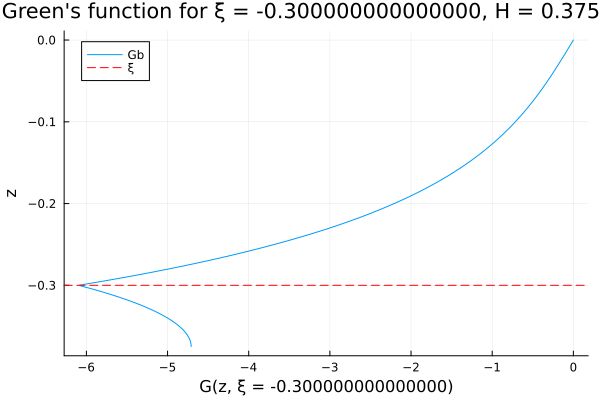

In [8]:
using Plots

this_x = -0.5
this_H = Hfn(this_x)
this_ξ = -this_H * 0.8           # Pick the value of ξ in [-H, 0]:

# Insert parameter values here and convert symbolic the symbolic G's function to a Julia function:
Gb_fixed(zᵢ,this_ξ) = Gb_num.subs([(ξ, this_ξ), (z, zᵢ),(x,this_x)])

# --- Plot ---
zvals = range(-this_H, 0, length=512)
Gbvals = [Gb_fixed(z_, this_ξ) |> float   for z_ in zvals]  # use float() to get a number
plt1 = plot(Gbvals, zvals; label="Gb",ylabel="z", xlabel="G(z, ξ = $this_ξ)", title="Buoyancy Green's function for ξ = $this_ξ, H = $this_H", legend=true)
hline!([this_ξ]; label="ξ", linestyle=:dash, color=:red)

# Plot diffusivity, viscosity, and buoyancy, and buoyancy derivative profiles

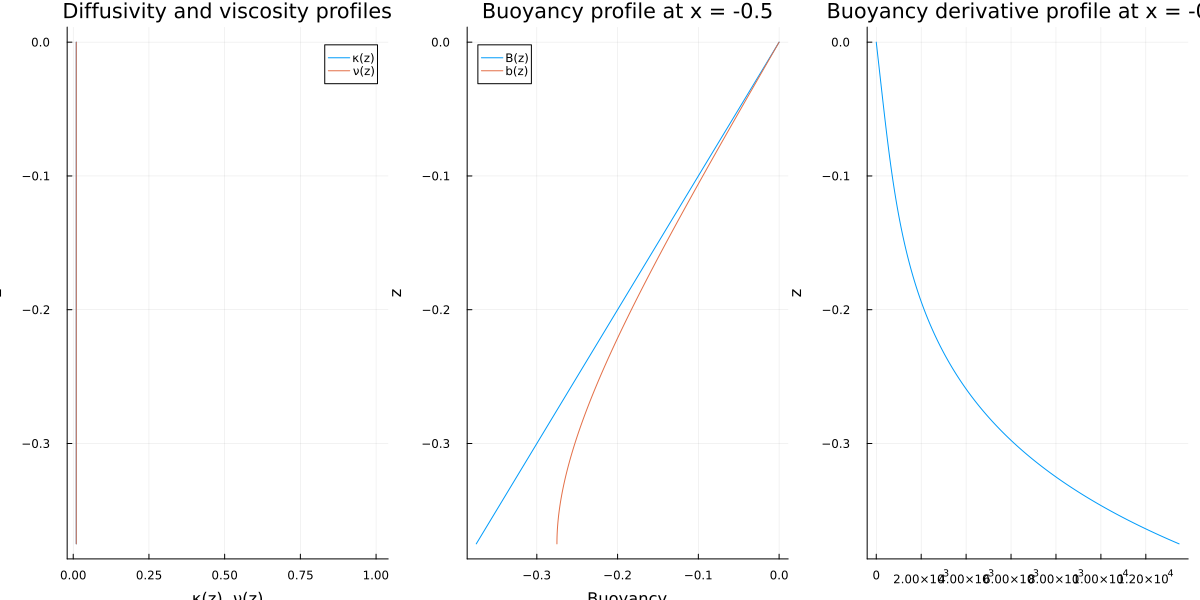

In [9]:
# Compute and plot diffusivity and viscosity:
κ_fixed(zᵢ) = κ.subs(param_values).subs([(H, this_H), (z, zᵢ)])
ν_fixed(zᵢ) = ν.subs(param_values).subs([(H, this_H), (z, zᵢ)])
κvals = [κ_fixed(z_) |> float for z_ in zvals]
νvals = [ν_fixed(z_) |> float for z_ in zvals]
# plt1 = plot(  κvals, zvals; label="κ(z)", ylabel="z", xlabel="κ(z), ν(z)", title="Diffusivity and viscosity profiles", xlims=(0,maximum(vcat(κvals,νvals)) * 1.1), ylims=(-this_H,0) )
plt1 = plot(  κvals, zvals; label="κ(z)", ylabel="z", xlabel="κ(z), ν(z)", title="Diffusivity and viscosity profiles")

plot!( νvals, zvals; label="ν(z)")

# Compute and plot relaxation buoyancy profile:
B_fixed(zᵢ) = Bfn.subs([(z, zᵢ)])
Bvals = [B_fixed(z_) |> float for z_ in zvals]
# plt2 = plot( Bvals, zvals, label="B(z)", ylabel="z", title="Buoyancy profile at x = $this_x", legend=false, xlims=(minimum(Bvals) * 1.1,maximum(Bvals) * 1.1), ylims=(-this_H,0))
plt2 = plot( Bvals, zvals, label="B(z)", ylabel="z", title="Buoyancy profile at x = $this_x", legend=false)

# Compute buoyancy profile at this_x, then plot:
function compute_b_profile(b_num, db_numdx, this_x, zvals)
    this_H         = Hfn(this_x)
    this_b         = simplify(b_num.subs(x,this_x))
    @assert simplify(diff(this_b,z).subs(z,-this_H)) < 1e-12            # Check Neumann BC at bottom
    @assert simplify(this_b.subs(z,0)) < 1e-12                          # Check Dirichlet BC at top    
    b_fixed(zᵢ)    = this_b.subs(z, zᵢ)

    x_in_expr      = get_var_in_expr("x",db_numdx)
    z_in_expr      = get_var_in_expr("z",db_numdx)
    this_dbdx      = simplify(db_numdx.subs(x_in_expr,this_x))
    dbdx_fixed(zᵢ) = this_dbdx.subs(z_in_expr, zᵢ)

    these_z_inds   = findall(zvals .>= -this_H)                           # Only compute down to the local depth
    these_z_vals   = zvals[these_z_inds]
    bvals          = [b_fixed(z_) |> float for z_ in these_z_vals]
    dbdxvals       = [dbdx_fixed(z_) |> float for z_ in these_z_vals]
    return bvals, dbdxvals, these_z_inds
end
b_vals, dbdx_vals, _ = compute_b_profile(b_num, db_numdx, this_x, zvals)
plot!(b_vals, zvals, label="b(z)", xlabel="Buoyancy", legend=true)

# Plot buoyancy derivative
plt3 = plot(dbdx_vals, zvals,  label="db(z)/dx", ylabel="z", title="Buoyancy derivative profile at x = $this_x", legend=false)
plot(plt1, plt2, plt3, layout=(1,3), size=(1200,600))

### Plot the buoyancy and buoyancy derivative fields by looping over different depths to construct them:

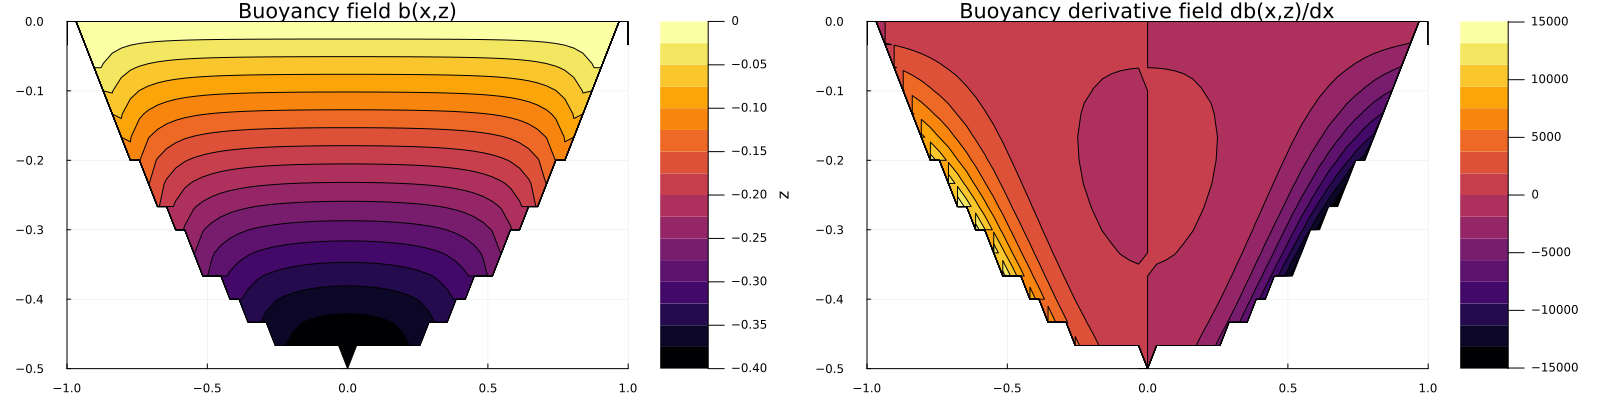

In [10]:
N = 16
# N = 8
xvals  = collect(range(-1, 0, length=2*N))
zvals  = float(collect(range(-maximum(Hfn.(collect(xvals))), 0; length=N)))
H_vals = float(Hfn.(collect(xvals)))
bz     = fill(NaN, length(zvals), length(xvals))
dbzdx  = fill(NaN, length(zvals), length(xvals))

for (x_ind, this_x) ∈ enumerate(xvals)
    b_values, dbdx_values, these_z_inds = compute_b_profile(b_num, db_numdx, this_x, zvals)
    bz[   these_z_inds, findfirst(==(this_x), xvals)] = b_values                 # Store b(x,z)
    dbzdx[these_z_inds, findfirst(==(this_x), xvals)] = dbdx_values              # Store dbdx(x,z)
end
# Assume symmetry to make plot look better:
plt_xvals = vcat(xvals[  1:end-1], -reverse(xvals))
plt_zvals = zvals
plt_bz    = hcat(   bz[:,1:end-1],  reverse(bz,   dims=2))
plt_dbzdx = hcat(dbzdx[:,1:end-1], -reverse(dbzdx,dims=2))
plt1 = contour(plt_xvals, plt_zvals, plt_bz;    xlabel="x", ylabel="z", title="Buoyancy field b(x,z)"               , fill=true)
plt2 = contour(plt_xvals, plt_zvals, plt_dbzdx; xlabel="x", ylabel="z", title="Buoyancy derivative field db(x,z)/dx", fill=true)
plot(plt1, plt2, layout=(1,2), size=(1600,400))

### Compute baroclinic potential energy $\chi (x)$ and plot it:

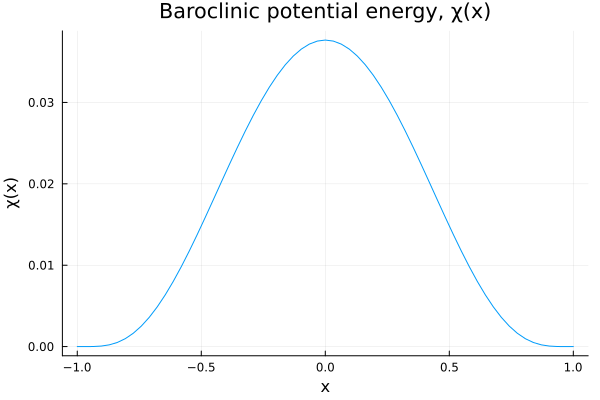

In [11]:
χ = fill(NaN, length(xvals))

for (x_ind, this_x) ∈ enumerate(xvals)
    local this_b = b_num.subs(x, this_x)
    local this_H = Hfn.subs(  x, this_x)
    χ[x_ind] = integrate(z * this_b,(z,-this_H,0))
end
plt_χ = vcat(χ[  1:end-1], reverse(χ))
plt = plot(plt_xvals,plt_χ;xlabel="x",ylabel="χ(x)",title="Baroclinic potential energy, χ(x)",legend=false)
display(plt)

# Resume work here!

In [12]:
# Try to compute the d\dz(uv) solution explicitly while carrying the unknown integration constants....

integrand0_sym = Guvz_sym * db_symdx
# uv_sym          = integrate(integrand0_sym,(ξ,-H(x),0))     # Find formula for uv (still with unknown constants).
integrand0_num = tom_subs(integrand0_sym,param_values)
integrand1_num = tom_subs(integrand0_num,Dict("Derivative(H(x), x)"=>string(diff(Hfn,x))))
integrand2_num = tom_subs(integrand1_num,Dict("B(-H(x))"=>string(Bfn(-Hfn(x)))))
integrand3_num = tom_subs(integrand2_num,Dict("H(x)"=>string(Hfn)))
integrand4_num = tom_subs(integrand3_num,Dict("B(ξ)"=>string(Bfn.subs(z,ξ))))
@time test     = integrate(integrand4_num,(get_var_in_expr("ξ",integrand4_num),-Hfn(this_x),0)) ;          # This computes OK, but is a MASSIVE expression.

 42.737968 seconds (145.29 k allocations: 3.120 MiB, 0.02% compilation time)


/                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                                                                              >
|                           

In [13]:
# For a particular (x,z) value:  THIS WORKS IN TERMS OF 1 UNKNOWN INTEGRATION CONSTANT
# this_z = this_x/2
this_z = -this_H
integrand5_num = integrand4_num.subs(get_var_in_expr("x",integrand4_num),this_x)
integrand6_num = integrand5_num.subs(get_var_in_expr("z",integrand5_num),this_z)
@time uvz_num  = integrate(integrand6_num,(get_var_in_expr("ξ",integrand6_num),-Hfn(this_x),0))           # This computes OK.
this_uvz_num   = uvz_num.doit().evalf()
this_uvz_num_real = real(this_uvz_num).evalf()
this_uvz_num_imag = imag(this_uvz_num).evalf()
@info "For (x,z), H = $this_x , $this_z, $this_H:"
@info "du/dz = $this_uvz_num_real,"
@info "dv/dz = $this_uvz_num_imag"

  1.294913 seconds (25.98 k allocations: 1.156 MiB, 0.53% compilation time)


┌ Info: For (x,z), H = -0.5 , -0.375000000000000, 0.375000000000000:
└ @ Main /Users/twnh/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/Meetings/ArcticOceanDynamics_Nov25/ArcticBoundaryCurrentModel/theory/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:10
┌ Info: du/dz = 0,
└ @ Main /Users/twnh/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/Meetings/ArcticOceanDynamics_Nov25/ArcticBoundaryCurrentModel/theory/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:11
┌ Info: dv/dz = 0
└ @ Main /Users/twnh/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/Meetings/ArcticOceanDynamics_Nov25/ArcticBoundaryCurrentModel/theory/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:12


#### For LaTeX write up:

In [14]:
kappa_var   = get_var_in_expr("κ₀",Gb_sym)
epsilon_var = get_var_in_expr("ϵ" ,Gb_sym)
gamma_var   = get_var_in_expr("γ" ,Gb_sym)
ϕ = gamma_var/(epsilon_var^2 * kappa_var)

tmp  = tom_subs(Gb_sym,Dict("γ"=>"ϕ^2 * ϵ^2 * κ₀ "))               # THIS IS FRAGILE!!!
tmp2 = tom_subs(tmp,Dict("sqrt(κ₀*ϕ^2*ϵ^2)/(sqrt(κ₀)*ϵ)"=>"ϕ"))
tmp3 = tom_subs(tmp2,Dict("sqrt(κ₀*ϕ^2*ϵ^2)"=>"ϕ*sqrt(κ₀)*ϵ"))
display("Simplified Gb(z,ξ)")
display(tmp3)

tmp4 = tom_subs(tmp3,Dict("ξ"=>"-H(x)"))
display("Simplified Gb(z,-H(x))")
display(simplify(tmp4.args[1].args[1]))

display("Simplified d/dx Gb(z,ξ)")
x_var = get_var_in_expr("x" ,tmp3)
tmp5  = simplify(diff(tmp3,x_var))
display(tmp5)

"Simplified Gb(z,ξ)"

//     -2*ξ*ϕ\ / 2*ϕ*H(x)    -2*z*ϕ\  ϕ*(z + ξ)            
|\1 - e      /*\e         + e      /*e                     
|----------------------------------------------  for z <= ξ
|                   / 2*ϕ*H(x)    \                        
|            2*κ₀*ϕ*\e         + 1/                        
<                                                          
|/     -2*z*ϕ\ / 2*ϕ*H(x)    -2*ξ*ϕ\  ϕ*(z + ξ)            
|\1 - e      /*\e         + e      /*e                     
|----------------------------------------------  for z >= ξ
|                   / 2*ϕ*H(x)    \                        
\            2*κ₀*ϕ*\e         + 1/                        

"Simplified Gb(z,-H(x))"

-cosh(ϕ*(z + H(x)))*tanh(ϕ*H(x)) 
---------------------------------
              κ₀*ϕ               

"Simplified d/dx Gb(z,ξ)"

//   2*z*ϕ    2*ξ*ϕ    2*ϕ*(z + ξ)    \  ϕ*(-z - ξ + 2*H(x)) d                 >
|\- e      - e      + e            + 1/*e                   *--(H(x))          >
|                                                            dx                >
<--------------------------------------------------------------------  for Or( >
|                     / 4*ϕ*H(x)      2*ϕ*H(x)    \                            >
|                  κ₀*\e         + 2*e         + 1/                            >
\                                                                              >

>                
>                
>                
> z >= ξ, z <= ξ)
>                
>                
>                

In [15]:
nu_var      = get_var_in_expr("ν₀",Guvz_sym)
epsilon_var = get_var_in_expr("ϵ" ,Guvz_sym)
f_var       = get_var_in_expr("f" ,Guvz_sym)
ϕ           = f_var/(epsilon_var^2 * nu_var)

tmp  = tom_subs(Guvz_sym,Dict("f"=>"ϕ^2 * ϵ^2 * ν₀"))               # THIS IS FRAGILE!!!
tmp2 = tom_subs(tmp,Dict("sqrt(ν₀*ϕ^2*ϵ^2)/(sqrt(ν₀)*ϵ)"=>"ϕ"))
tmp3 = tom_subs(tmp2,Dict("sqrt(ν₀*ϕ^2*ϵ^2)"=>"ϕ*sqrt(ν₀)*ϵ"))
display("Simplified Guvz(z,ξ)")
display(tmp3)

"Simplified Guvz(z,ξ)"

/     /         ___    \ /         ___             \     ___                   >
| 3/2 |     2*\/ I *ξ*ϕ| |     2*\/ I *ϕ*(z + H(x))|  -\/ I *ϕ*(z + ξ)         >
|I   *\1 - e           /*\1 - e                    /*e                         >
|---------------------------------------------------------------------  for z  >
|                           /         ___       \                              >
|                           |     2*\/ I *ϕ*H(x)|                              >
|                    2*ν₀*ϕ*\1 - e              /                              >
<                                                                              >
|     /         ___    \ /         ___             \     ___                   >
| 3/2 |     2*\/ I *z*ϕ| |     2*\/ I *ϕ*(ξ + H(x))|  -\/ I *ϕ*(z + ξ)         >
|I   *\1 - e           /*\1 - e                    /*e                         >
|---------------------------------------------------------------------  for z  >
|                           

In [16]:
xi_var = get_var_in_expr("ξ" ,tmp3)
tmp4 = tom_subs(diff(tmp3,xi_var),Dict("ξ"=>"0"))
display("Simplified d/dξ Guvz(z,ξ)_{ξ = 0}")
display(simplify(tmp4.args[1].args[1]))
tmp5 = tom_subs(diff(tmp3,xi_var),Dict("ξ"=>"-H(x)"))
display("Simplified d/dξ Guvz(z,ξ)_{ξ = -H(x)}")
display(simplify(tmp5.args[2].args[1]))

"Simplified d/dξ Guvz(z,ξ)_{ξ = 0}"

/         ___             \     ___    
|     2*\/ I *ϕ*(z + H(x))|  -\/ I *z*ϕ
\1 - e                    /*e          
---------------------------------------
          /         ___       \        
          |     2*\/ I *ϕ*H(x)|        
       ν₀*\1 - e              /        

"Simplified d/dξ Guvz(z,ξ)_{ξ = -H(x)}"

/         ___    \     ___             
|     2*\/ I *z*ϕ|  -\/ I *ϕ*(z - H(x))
\1 - e           /*e                   
---------------------------------------
          /         ___       \        
          |     2*\/ I *ϕ*H(x)|        
       ν₀*\1 - e              /        

In [23]:
z_var = get_var_in_expr("z" ,tmp3)
z1 = symbols("z1", real=true, negative=true)
tmp3i = integrate(tmp3, (z_var, -H(x), z1))
expr = tmp3i.args[1].args[1]
expr = tom_subs(expr,Dict("Min(z1, -H(x))"=>"-H(x)"))
expr = tom_subs(expr,Dict("Max(ξ, -H(x))"=>"ξ"))
display("Simplified ∫ Guvz(z,ξ) dz from -H(x) to z1")
display(simplify(expr))

z1_var = get_var_in_expr("z1" ,tmp3i)
tmp3ii = integrate(tmp3i, (z1_var, -H(x), 0))
expr = simplify(tmp3ii.args[1].args[1])
expr = tom_subs(expr,Dict("Max(ξ, -H(x))"=>"ξ"))
expr = tom_subs(expr,Dict("Min(0, ξ)"=>"ξ"))
display("Simplified ∫∫ Guvz(z,ξ) dz1 from -H(x) to z1 and dz1 from -H(x) to 0")
display(simplify(expr)) 

"Simplified ∫ Guvz(z,ξ) dz from -H(x) to z1"

   /   ___                   ___                            ___                >
   | \/ I *ϕ*(z1 + 2*ξ)    \/ I *ϕ*(z1 + 2*Min(z1, ξ))    \/ I *ϕ*(2*z1 + Min( >
   |e                     e                              e                     >
-I*|------------------- + ---------------------------- - --------------------- >
   \         2                         2                              2        >
------------------------------------------------------------------------------ >
                                                                               >
                                                                               >
                                                                               >

>              ___                                                             >
> z1, ξ))    \/ I *ϕ*(z1 + 2*ξ + 2*H(x))      ___                              >
>           e                               \/ I *ϕ*(z1 + H(x) + Min(z1, ξ))   >
> ------- - ---------------

"Simplified ∫∫ Guvz(z,ξ) dz1 from -H(x) to z1 and dz1 from -H(x) to 0"

  /     ___                       ___                            ___           >
  |   \/ I *ϕ*(2*ξ + H(x))      \/ I *ϕ*(2*ξ + 3*H(x))         \/ I *ϕ*(ξ + 2* >
I*\ξ*e                     - ξ*e                       - H(x)*e                >
------------------------------------------------------------------------------ >
                                                             /     ___         >
                                                           2 | 2*\/ I *ϕ*H(x)  >
                                                       ν₀*ϕ *\e                >

>                 ___                 \     ___               
> H(x))         \/ I *ϕ*(3*ξ + 2*H(x))|  -\/ I *ϕ*(2*ξ + H(x))
>       + H(x)*e                      /*e                     
> ------------------------------------------------------------
>    \                                                        
>    |                                                        
> - 1/                                                

In [ ]:
z1 = symbols("z1", real=true, negative=true)
tmp6 = integrate(tmp4.args[1].args[1], (z_var, -H(x), z1))
display("Simplified ∫ d/dξ Guvz(z,ξ)_{ξ = 0} dz from -H(x) to z1")
display(simplify(tmp6.args[1].args[1]))

z1_var = get_var_in_expr("z1" ,tmp6)
tmp7 = integrate(tmp6.args[1].args[1], (z1_var, -H(x), 0))
display("Simplified ∫∫ d/dξ Guvz(z,ξ)_{ξ = 0} dz1 from -H(x) to z1 and dz1 from -H(x) to 0")
display(simplify(tmp7.args[1].args[1])) 

"Simplified ∫ d/dξ Guvz(z,ξ)_{ξ = 0} dz from -H(x) to z1"

     /   ___                      ___                      ___                 >
 3/2 | \/ I *ϕ*(z1 + 2*H(x))    \/ I *ϕ*(z1 + 2*H(x))    \/ I *ϕ*(2*z1 + H(x)  >
I   *\e                      + e                      - e                      >
------------------------------------------------------------------------------ >
                                                       /     ___           \   >
                                                       | 2*\/ I *ϕ*H(x)    |   >
                                                  ν₀*ϕ*\e               - 1/   >

>                ___       \     ___              
> + 2*H(x))    \/ I *ϕ*H(x)|  -\/ I *ϕ*(z1 + H(x))
>           - e            /*e                    
> ------------------------------------------------
>                                                 
>                                                 
>                                                 

"Simplified ∫∫ d/dξ Guvz(z,ξ)_{ξ = 0} dz1 from -H(x) to z1 and dz1 from -H(x) to 0"

          ___             
       -\/ I *ϕ*H(x)      
      e                   
--------------------------
     /     ___           \
     | 2*\/ I *ϕ*H(x)    |
ν₀*ϕ*\e               - 1/

In [18]:
tmp8 = integrate(tmp5.args[2].args[1], (z_var, -H(x), z1))
display("Simplified ∫ d/dξ Guvz(z,ξ)_{ξ = -H(x)} dz from -H(x) to z1")
display(simplify(tmp8.args[1].args[1]))
tmp9 = integrate(tmp8.args[1].args[1], (z1_var, -H(x), 0))
display("Simplified ∫∫ d/dξ Guvz(z,ξ)_{ξ = -H(x)} dz1 from -H(x) to z1 and dz1 from -H(x) to 0")
display(simplify(tmp9.args[1].args[1])) 

"Simplified ∫ d/dξ Guvz(z,ξ)_{ξ = -H(x)} dz from -H(x) to z1"

     /   ___           ___                      ___                      ___   >
 3/2 | \/ I *z1*ϕ    \/ I *ϕ*(z1 + 2*H(x))    \/ I *ϕ*(2*z1 + H(x))    \/ I *ϕ >
I   *\e           + e                      - e                      - e        >
------------------------------------------------------------------------------ >
                                                /     ___           \          >
                                                | 2*\/ I *ϕ*H(x)    |          >
                                           ν₀*ϕ*\e               - 1/          >

>      \     ___                     
> *H(x)|  -\/ I *ϕ*(z1 + H(x) - H(x))
>      /*e                           
> -----------------------------------
>                                    
>                                    
>                                    

"Simplified ∫∫ d/dξ Guvz(z,ξ)_{ξ = -H(x)} dz1 from -H(x) to z1 and dz1 from -H(x) to 0"

          ___             
       -\/ I *ϕ*H(x)      
      e                   
--------------------------
     /     ___           \
     | 2*\/ I *ϕ*H(x)    |
ν₀*ϕ*\e               - 1/